In [ ]:
suppressPackageStartupMessages({
    library(ggplot2)
    library(Seurat)
    library(dplyr)
    library(tidyr)
    library(tibble)
    library(stringr)
    library(dittoSeq)
    library(patchwork)
    library(future)
    plan("multicore", workers = 24)
    options(future.globals.maxSize = 1000 * 1024^5)
    options(stringsAsFactors = FALSE)
    set.seed(123)
})

Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”


## Malignant

In [ ]:
sussman2024 <- readRDS('/projects/0/einf2548/cruiz/dmg/public_data/Sussman2024/Final_Cohort_All_snRNA-seq_H3K27_H3WT.RDS')
sussman2024

In [ ]:
sussman2024_malignant <- subset(sussman2024, merged_cellType == 'Neuroglial'
                               )
sussman2024_malignant

In [ ]:
DefaultAssay(sussman2024_malignant) <- 'RNA'
sussman2024_malignant <-NormalizeData(sussman2024_malignant) %>% FindVariableFeatures() %>%ScaleData()%>%RunPCA(verbose = FALSE)

Centering and scaling data matrix



In [ ]:
malignant <- readRDS('/projects/0/einf2548/cruiz/dmg/data/malignant_rna.rds')
malignant

An object of class Seurat 
19248 features across 291695 samples within 1 assay 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap

In [ ]:
malignant <- AddMetaData(malignant , readRDS('nmf/data//nmf_assigment_malignant_no_core_programs.rds'))

In [ ]:
malignant <- subset(malignant, iCNV == 'tumor')
malignant

An object of class Seurat 
19248 features across 258867 samples within 1 assay 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap

In [ ]:
malignant$MP_Assignment <- sub("_1$", "", malignant$MP_Assignment)
malignant$MP_Assignment <- sub("_", "", malignant$MP_Assignment)

In [ ]:
table(malignant$MP_Assignment)


      MP11       MP12       MP13        MP2        MP3        MP4        MP5 
     11024       3798       3439      64880      43453      37301      14699 
       MP7        MP8        MP9 unresolved 
     29669       9723      16137      24744 

In [ ]:
malignant <- subset(malignant, MP_Assignment != 'unresolved')
malignant

An object of class Seurat 
19248 features across 234123 samples within 1 assay 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap

In [ ]:
malignant$lvl_4 <- recode(malignant$MP_Assignment,
                         'MP11'='Tri_IPC_like',
                         'MP12'='nIPC_like',
                         'MP13'='GBL_like',
                         'MP2'='OPC_like',
                         'MP3'='AC_like',
                         'MP4'='RG_like',
                         'MP5'='COP_like',
                         'MP7'='TD_like',
                         'MP8'='Cilia_like',
                         'MP9'='GW_like'
                         )

In [ ]:
malignant <- RunPCA(malignant)

PC_ 1 
Positive:  TUBB2B, DBI, NDUFA4, RPL32, RPL15, RPS18, RPL29, RPL7, MIF, RPL35A 
	   GAPDH, LDHB, RPL19, RPL8, RPL18A, FABP7, RPS15A, COX7A2, RPL39, RPS2 
	   RPL30, RPL14, RPS17, CHCHD2, RPL23A, YBX1, RPS8, RPS6, RPL27, RPL9 
Negative:  ROBO2, LUZP2, NKAIN3, AGBL4, DNAH7, SLC4A4, RFX4, FAM135B, TMEM232, CCSER1 
	   CFAP54, FOXP2, RNF19A, PLCG2, WDR49, EFEMP1, LDB2, SLIT2, MGAT4C, CADPS 
	   GPC5, PRKG1, GABRB1, EYA1, ADGRV1, MECOM, FAM189A2, ABI3BP, LAMA2, TMEM163 
PC_ 2 
Positive:  DTHD1, CFAP54, SPAG17, CFAP157, CFAP299, ZBBX, ARMC3, CFAP43, VWA3A, DNAH5 
	   TTC29, CFAP73, CFAP47, DCDC1, CAPS, DNAH7, DAW1, RSPH1, ADGB, SPATA17 
	   TCTEX1D1, DNAI1, TOGARAM2, C8orf34, DNAAF1, TMEM232, CFAP221, CFAP46, CLU, DNAH11 
Negative:  FGF12, CA10, NXPH1, SNTG1, KCNIP4, PDGFRA, STK32B, PCDH11X, BCAS1, ACAN 
	   SEZ6L, POLR2F, RAB27B, SOX4, KIF18B, KCNH7, TMEM132D, BMPER, GPC3, ADAMTSL1 
	   RAB3C, HECW1, CNTNAP5, SLC22A3, RRM2, KIF14, ASPM, GPR17, TMEM132C, GRM5 
PC_ 3 
Positive:  ASPM, C

### Reference mapping

In [ ]:
anchors <- FindTransferAnchors(
  reference = malignant,
  query = sussman2024_malignant,
  features = rownames(malignant[["RNA"]]),
  normalization.method = "LogNormalize",
  reference.reduction = "pca",
  dims = 1:50
)

Warning message:
“930 features of the features specified were not present in both the reference query assays. 
Continuing with remaining 18318 features.”
Projecting cell embeddings

Finding neighborhoods

Finding anchors

	Found 39751 anchors



`Map Query` functions run separately

In [ ]:
sussman2024_malignant <- TransferData(
  anchorset = anchors, 
  reference = malignant,
  query = sussman2024_malignant,
  refdata = list(
      atlas = 'lvl_4'
  ),
)

Finding integration vectors

Finding integration vector weights

Predicting cell labels

Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Layer counts isn't present in the assay object; returning NULL”


In [ ]:
sussman2024_malignant <- IntegrateEmbeddings(
  anchorset = anchors,
  reference = malignant,
  query = sussman2024_malignant, 
  new.reduction.name = "ref.pca"
)

Warning message:
“Layer counts isn't present in the assay object; returning NULL”
Warning message:
“Layer counts isn't present in the assay object; returning NULL”

Integrating dataset 2 with reference dataset

Finding integration vectors

Integrating data



In [ ]:
sussman2024_malignant$predicted.atlas <- factor(sussman2024_malignant$predicted.atlas,
                                               levels=c(
                     'RG_like', 'GBL_like','Tri_IPC_like','nIPC_like','OPC_like',
'COP_like','AC_like','Cilia_like','TD_like','GW_like'
                     )
                                               )

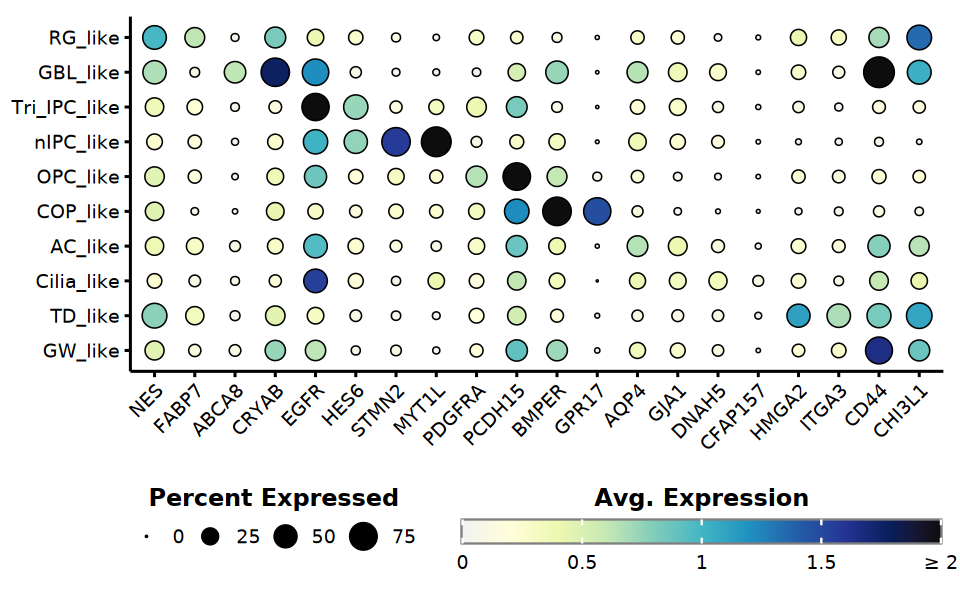

In [ ]:
options(repr.plot.height = 5, repr.plot.width = 8)
SCpubr::do_DotPlot(sussman2024_malignant,
                  c('NES', 'FABP7', 
                  'ABCA8', 'CRYAB', 
                  'EGFR', 'HES6', 
                  'STMN2', 'MYT1L', 
                  'PDGFRA', 'PCDH15', 
                  'BMPER', 'GPR17', 
                  'AQP4', 'GJA1', 
                  'DNAH5', 'CFAP157',
                    'HMGA2','ITGA3',
                    'CD44','CHI3L1'
  ), group.by='predicted.atlas', max.cutoff = 2
                  )

In [ ]:
saveRDS(sussman2024_malignant, '/projects/0/einf2548/cruiz/dmg/public_data/Sussman2024/Final_Cohort_All_snRNA-seq_H3K27_H3WT_malignant.RDS')

## Myeloid

In [ ]:
sussman2024 <- readRDS('/projects/0/einf2548/cruiz/dmg/public_data/Sussman2024/Final_Cohort_All_snRNA-seq_H3K27_H3WT.RDS')

In [ ]:
sussman2024 <- subset(sussman2024, merged_cellType=='Macrophage/Microglia')

In [ ]:
DefaultAssay(sussman2024) <- 'RNA'
sussman2024 <-NormalizeData(sussman2024) %>% FindVariableFeatures() %>%ScaleData()%>%RunPCA(verbose = FALSE) %>% RunUMAP(verbose=FALSE, dims=1:15)

Centering and scaling data matrix

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by ‘BiocGenerics’

Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by ‘BiocGenerics’



In [ ]:
myeloid <- readRDS('/projects/0/einf2548/cruiz/dmg/data/myeloid_rna.rds')
myeloid

An object of class Seurat 
19248 features across 60672 samples within 1 assay 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap

In [ ]:
myeloid <- subset(myeloid, MP_Assignment != 'unresolved')
myeloid

An object of class Seurat 
19248 features across 59217 samples within 1 assay 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap

In [ ]:
myeloid$lvl_4 <- recode(myeloid$MP_Assignment,
                         'MP10'='TAM_homeostatic',
                         'MP2'='TAM_C1Q',
                         'MP4'='Mono_neutrophil',
                         'MP7'='TAM_IL1B',
                         'MP8'='TAM_scavenger',
                         'MP9'='TAM_lipid_laden'
                         )

In [ ]:
myeloid <- RunPCA(myeloid)

PC_ 1 
Positive:  MAP1B, LUZP2, ROBO2, CLU, SYT1, CADPS, GFAP, TENM2, KCNIP4, TMEM108 
	   PMP2, RFX4, NRXN3, FGF12, SNTG1, GPR158, ANK3, NKAIN3, TNC, SPOCK1 
	   AKAP12, EYA1, RBFOX1, AGBL4, KCNQ5, SLIT2, PTPRT, PDE10A, GRB10, CCSER1 
Negative:  C1QB, C1QA, HLA-DRA, C1QC, TYROBP, HLA-DPA1, CD74, FCER1G, CYBA, HLA-DPB1 
	   LAPTM5, ALOX5AP, AIF1, RNASET2, SRGN, S100A11, NPC2, SPP1, CD14, APOC1 
	   TMSB4X, HLA-DRB1, FCGR3A, TMIGD3, RGS10, APOC2, FTL, CCL3, RGS1, HLA-B 
PC_ 2 
Positive:  ARHGAP15, DOCK8, ADAM28, ATP8B4, FMN1, APBB1IP, BNC2, KYNU, FLI1, ACSL1 
	   SAMSN1, PTPRC, TLR2, CPED1, RNF144B, TFEC, LYN, MSR1, KCNQ3, SLC11A1 
	   KLHL6, PRKAG2, ARHGAP18, DLEU7, CD86, LCP2, EPSTI1, MS4A14, ITGAX, IPCEF1 
Negative:  AIF1, RPS23, RPL10A, EEF1B2, RPL12, RPS3A, RPL30, RPL37, RPL23A, RPS21 
	   RPL21, RPS13, RPS4X, RPS12, RPL39, RPS14, RPS7, RPL26, RPL29, RPS3 
	   RPL19, RPS11, UBA52, RPL7A, RPL18A, RPL9, RPS8, RPL27, RPS15A, RPL18 
PC_ 3 
Positive:  IPCEF1, P2RY12, HS3ST4, CX3CR1, OPR

### Reference mapping

In [ ]:
anchors <- FindTransferAnchors(
  reference = myeloid,
  query = sussman2024,
  features = rownames(myeloid[["RNA"]]),
  normalization.method = "LogNormalize",
  reference.reduction = "pca",
  dims = 1:50
)

Warning message:
“930 features of the features specified were not present in both the reference query assays. 
Continuing with remaining 18318 features.”
Projecting cell embeddings

Finding neighborhoods

Finding anchors

	Found 3996 anchors



`Map Query` functions run separately

In [ ]:
sussman2024 <- TransferData(
  anchorset = anchors, 
  reference = myeloid,
  query = sussman2024,
  refdata = list(
      atlas = 'lvl_4'
  ),
)

Finding integration vectors

Finding integration vector weights

Predicting cell labels

Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Layer counts isn't present in the assay object; returning NULL”


In [ ]:
sussman2024 <- IntegrateEmbeddings(
  anchorset = anchors,
  reference = myeloid,
  query = sussman2024, 
  new.reduction.name = "ref.pca"
)

Warning message:
“Layer counts isn't present in the assay object; returning NULL”
Warning message:
“Layer counts isn't present in the assay object; returning NULL”

Integrating dataset 2 with reference dataset

Finding integration vectors

Integrating data



In [ ]:
sussman2024$predicted.atlas <- factor(sussman2024$predicted.atlas,
                                               levels=c(
'Mono_neutrophil',
'TAM_C1Q','TAM_lipid_laden','TAM_scavenger','TAM_IL1B','TAM_homeostatic'
                     )
                                               )

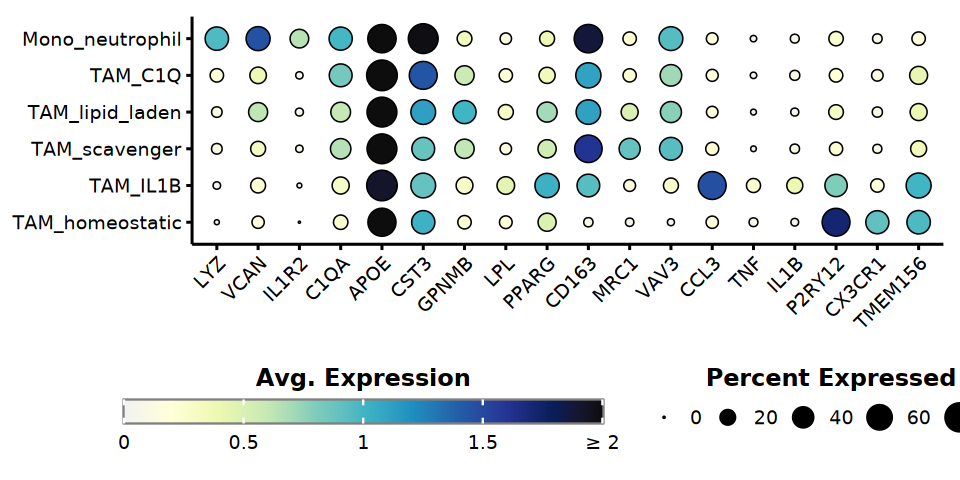

In [ ]:
genes <- c("LYZ", "VCAN", "IL1R2", 
           "C1QA", "APOE", "CST3",
           "GPNMB", "LPL", "PPARG",
           "CD163", "MRC1", "VAV3", 
            "CCL3", "TNF", "IL1B", 
          "P2RY12", "CX3CR1", "TMEM156"
          )

options(repr.plot.height = 4, repr.plot.width = 8)
SCpubr::do_DotPlot(sussman2024,
                  genes, 
                   group.by='predicted.atlas', max.cutoff = 2
                  )

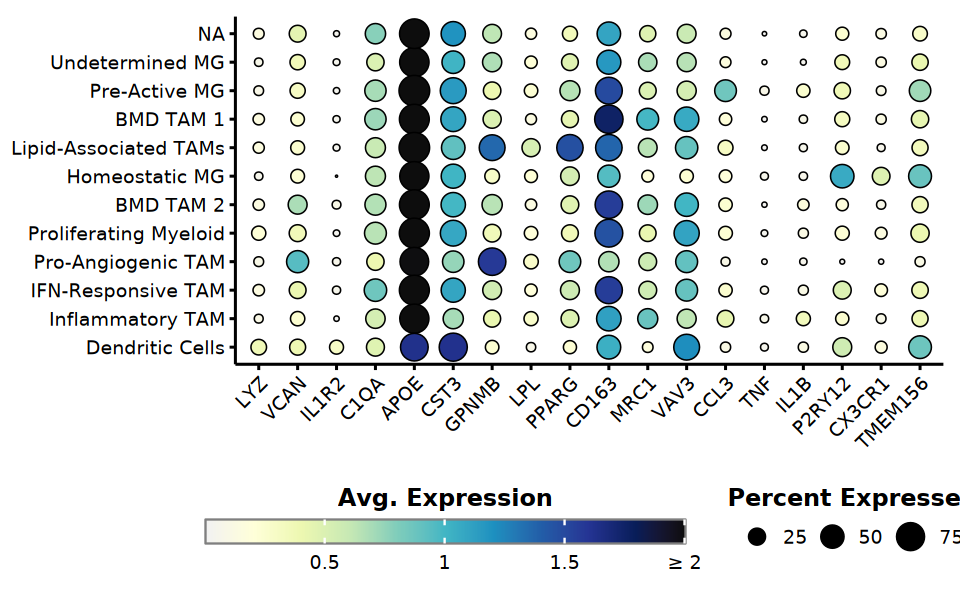

In [ ]:
genes <- c("LYZ", "VCAN", "IL1R2", 
           "C1QA", "APOE", "CST3",
           "GPNMB", "LPL", "PPARG",
           "CD163", "MRC1", "VAV3", 
            "CCL3", "TNF", "IL1B", 
          "P2RY12", "CX3CR1", "TMEM156"
          )

# author's label
options(repr.plot.height = 5, repr.plot.width = 8)
SCpubr::do_DotPlot(sussman2024,
                  genes, 
                   group.by='cell_labels1', max.cutoff = 2
                  )

In [ ]:
table(droplevels(sussman2024$predicted.atlas))


Mono_neutrophil         TAM_C1Q TAM_lipid_laden   TAM_scavenger        TAM_IL1B 
           5600            1918            2705            7341             464 
TAM_homeostatic 
             77 

In [ ]:
saveRDS(sussman2024, '/projects/0/einf2548/cruiz/dmg/public_data/Sussman2024/Final_Cohort_All_snRNA-seq_H3K27_H3WT_myeloid.RDS')